# Sentiment signal portfolio optimisation
## Findings, uncertainty, and implementation diagnostics

**Objective.** Summarise the four portfolio-selection questions using the frozen gross and net runs, while making selection uncertainty, signal redundancy, transaction-cost sensitivity, and Lagrange-weight instability visible.

> **Evidence status.** Exploratory, in-sample selection study on a previously examined cohort; specified after the Week 6 results. The development block selects subsets and weights. The evaluation block is reported once for frozen choices. This is neither preregistered confirmatory evidence nor deployable alpha.

**Frozen design:** seven scorer return series; common threshold `0.0`; one-session holding period; 10 bps per side on position changes; 252-session annualisation; zero risk-free rate; 85 development and 38 evaluation sessions after removing five structurally inactive sessions.

## Analysis plan

1. Verify the immutable run artifacts against their recorded SHA-256 hashes.
2. Answer the best-pair, best-triple, free-cardinality, and two-signal weighting questions.
3. Separate point estimates from uncertainty and out-of-sample behaviour.
4. Diagnose *why* equal-weight averaging fails: search geometry and return correlation.
5. Quantify selection luck with the exact demeaned moving-block no-edge null.
6. Show the geometry and practical instability of the unconstrained Lagrange solution.

The plots deliberately avoid decorative smoothing. Every highlight corresponds to a frozen rule or a statistic in the run manifest.

In [1]:
from pathlib import Path
import hashlib
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 20260729
np.random.seed(SEED)

ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
assert (ROOT / "pyproject.toml").exists(), "Run from inside the dissertation repository"

GROSS_DIR = ROOT / "results/signal_portfolio/sentiment_signal_portfolio_gross_h1_20260729"
NET_DIR = ROOT / "results/signal_portfolio/sentiment_signal_portfolio_net_h1_20260729"

PALETTE = {
    "navy": "#1B365D",
    "blue": "#3B6FB6",
    "teal": "#1B998B",
    "rust": "#B24C3D",
    "gold": "#D4A72C",
    "grey": "#6B7280",
    "light": "#E5E7EB",
    "ink": "#202124",
}

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.family": "DejaVu Serif",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "axes.edgecolor": PALETTE["ink"],
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8.5,
    "legend.frameon": False,
    "grid.color": "#D1D5DB",
    "grid.linewidth": 0.55,
    "grid.alpha": 0.7,
})

SHORT = {
    "headline/actionable_sentiment_all": "Actionable lexicon",
    "headline/sentiment_all": "All-headline lexicon",
    "headline/sentiment_non_reuters": "Non-Reuters lexicon",
    "headline/sentiment_reuters": "Reuters lexicon",
    "llm/finbert": "FinBERT",
    "llm/gemma-4-31b": "Gemma-4 31B",
    "llm/vader": "VADER",
}

def short_signal(value: str) -> str:
    return SHORT.get(value, value)


## 1. Reproducibility and frozen inputs

In [2]:
def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1 << 20), b""):
            digest.update(chunk)
    return digest.hexdigest()


def verify_run(run_dir: Path) -> tuple[dict, list[dict]]:
    manifest = json.loads((run_dir / "manifest.json").read_text())
    checks = []
    for filename, expected in manifest["output_hashes"].items():
        observed = sha256(run_dir / filename)
        checks.append({
            "run": manifest["configuration"]["return_variant"],
            "artifact": filename,
            "verified": observed == expected,
        })
    return manifest, checks


gross_manifest, gross_checks = verify_run(GROSS_DIR)
net_manifest, net_checks = verify_run(NET_DIR)
verification = pd.DataFrame(gross_checks + net_checks)
assert verification["verified"].all()

pd.DataFrame({
    "run": ["gross", "net"],
    "development sessions": [gross_manifest["development_evaluation"]["development_sessions"], net_manifest["development_evaluation"]["development_sessions"]],
    "evaluation sessions": [gross_manifest["development_evaluation"]["evaluation_sessions"], net_manifest["development_evaluation"]["evaluation_sessions"]],
    "artifacts verified": [sum(row["verified"] for row in gross_checks), sum(row["verified"] for row in net_checks)],
    "exploratory": [gross_manifest["analysis"]["exploratory"], net_manifest["analysis"]["exploratory"]],
    "preregistered": [gross_manifest["analysis"]["preregistered"], net_manifest["analysis"]["preregistered"]],
}).style.hide(axis="index")


run,development sessions,evaluation sessions,artifacts verified,exploratory,preregistered
gross,85,38,7,True,False
net,85,38,7,True,False


In [3]:
gross_subsets = pd.read_csv(GROSS_DIR / "subset_sharpe.csv")
net_subsets = pd.read_csv(NET_DIR / "subset_sharpe.csv")
gross_panel = pd.read_csv(GROSS_DIR / "signal_panel.csv", parse_dates=["date", "split_date"])
gross_correlations = pd.read_csv(GROSS_DIR / "development_correlations.csv", index_col=0)
pair_weights = pd.read_csv(GROSS_DIR / "pair_weight_solutions.csv")
stability = pd.read_csv(GROSS_DIR / "stability_certificates.csv")

signal_order = list(SHORT)
assert set(gross_panel["signal"]) == set(signal_order)
assert len(gross_subsets) == 2 ** len(signal_order) - 1 == 127
assert gross_panel.groupby("signal")["date"].nunique().nunique() == 1

matrix_gross = gross_panel.pivot(index="date", columns="signal", values="daily_gross_return").sort_index()
matrix_net = gross_panel.pivot(index="date", columns="signal", values="daily_net_return").sort_index()
splits = gross_panel.groupby("date")["split"].first().reindex(matrix_gross.index)
development = matrix_gross.loc[splits.eq("development")]
evaluation = matrix_gross.loc[splits.eq("evaluation")]

best_by_k = (
    gross_subsets.loc[gross_subsets.groupby("size")["development_sharpe"].idxmax()]
    .sort_values("size")
    .reset_index(drop=True)
)
best_pair_signals = best_by_k.loc[best_by_k["size"].eq(2), "signals"].iloc[0].split("|")
best_triple_signals = best_by_k.loc[best_by_k["size"].eq(3), "signals"].iloc[0].split("|")
best_single = best_by_k.loc[best_by_k["size"].eq(1), "signals"].iloc[0]

stable = stability.loc[stability["is_add_drop_stable"]]
assert stable["signals"].tolist() == [best_single]


## 2. Answers to the four optimisation questions

In [4]:
pair_key = "|".join(best_pair_signals)
weight_row = pair_weights.loc[
    pair_weights["signal_a"].eq(best_pair_signals[0])
    & pair_weights["signal_b"].eq(best_pair_signals[1])
].iloc[0]

answers = pd.DataFrame([
    {
        "question": "Best 2, equal weighted",
        "answer": " + ".join(short_signal(s) for s in best_pair_signals),
        "development Sharpe": best_by_k.loc[best_by_k["size"].eq(2), "development_sharpe"].iloc[0],
        "evaluation Sharpe": best_by_k.loc[best_by_k["size"].eq(2), "evaluation_sharpe"].iloc[0],
    },
    {
        "question": "Best 3, equal weighted",
        "answer": " + ".join(short_signal(s) for s in best_triple_signals),
        "development Sharpe": best_by_k.loc[best_by_k["size"].eq(3), "development_sharpe"].iloc[0],
        "evaluation Sharpe": best_by_k.loc[best_by_k["size"].eq(3), "evaluation_sharpe"].iloc[0],
    },
    {
        "question": "Free cardinality; add/drop stable",
        "answer": short_signal(best_single),
        "development Sharpe": best_by_k.loc[best_by_k["size"].eq(1), "development_sharpe"].iloc[0],
        "evaluation Sharpe": best_by_k.loc[best_by_k["size"].eq(1), "evaluation_sharpe"].iloc[0],
    },
    {
        "question": "Lagrange weights for best pair",
        "answer": f"{weight_row.weight_a:.3f} / {weight_row.weight_b:.3f}",
        "development Sharpe": weight_row.optimal_sharpe,
        "evaluation Sharpe": weight_row.evaluation_sharpe_at_frozen_weights,
    },
])
answers.style.format({"development Sharpe": "{:.3f}", "evaluation Sharpe": "{:.3f}"}).hide(axis="index")


question,answer,development Sharpe,evaluation Sharpe
"Best 2, equal weighted",All-headline lexicon + Non-Reuters lexicon,1.178,0.344
"Best 3, equal weighted",All-headline lexicon + Non-Reuters lexicon + FinBERT,1.104,0.626
Free cardinality; add/drop stable,All-headline lexicon,1.274,0.576
Lagrange weights for best pair,6.768 / -5.768,1.772,2.283


The free-cardinality optimum is the singleton **All-headline lexicon**. It is the only subset for which every one-signal addition and every defined one-signal removal lowers development Sharpe. The Lagrange solution beats the equal-weight pair *in sample*, but does so by taking large offsetting positions rather than by finding a stable long-only mix.

## 3. Point estimates, uncertainty, and evaluation behaviour

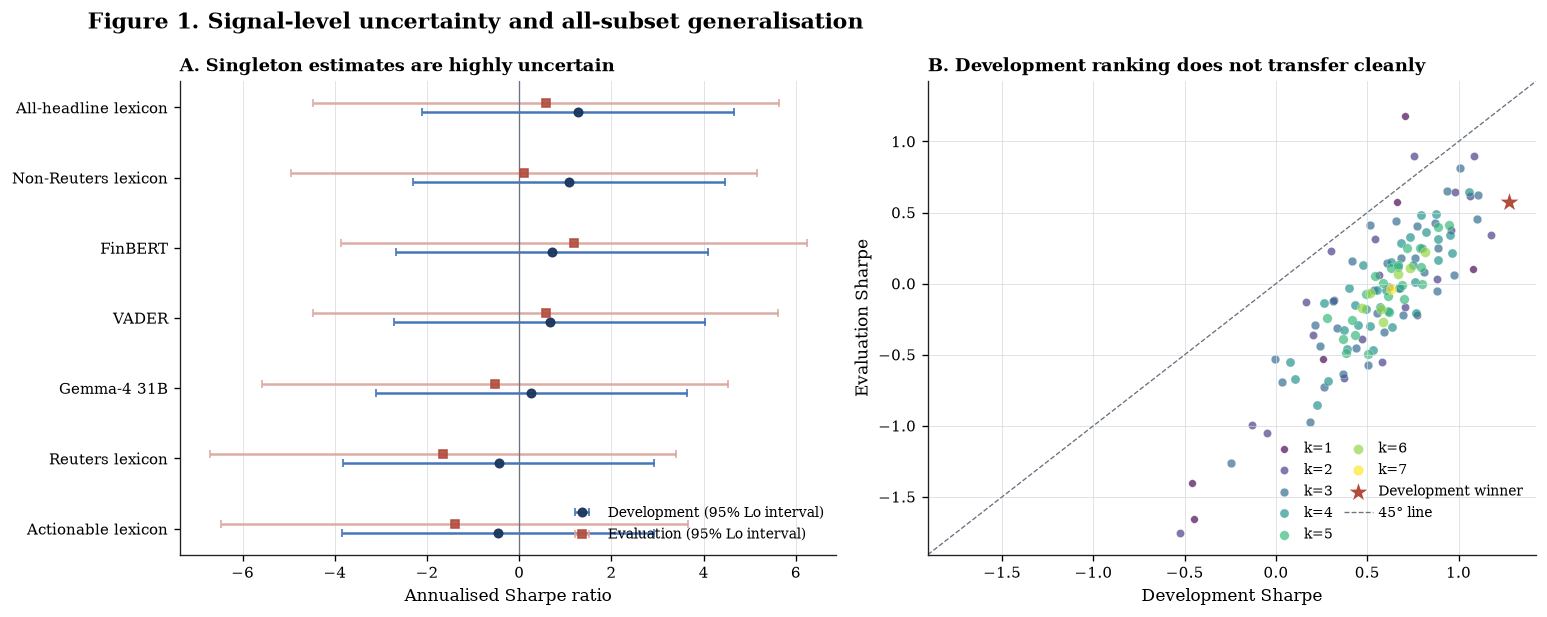

In [5]:
singletons = gross_subsets.loc[gross_subsets["size"].eq(1)].copy()
singletons["label"] = singletons["signals"].map(short_signal)
singletons = singletons.sort_values("development_sharpe")

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.2), gridspec_kw={"width_ratios": [1.08, 1.0]})

# A: Honest point-range plot using the recorded Lo standard errors.
y = np.arange(len(singletons))
axes[0].errorbar(
    singletons["development_sharpe"], y,
    xerr=1.96 * singletons["development_sharpe_standard_error"],
    fmt="o", ms=5, capsize=2.5, color=PALETTE["navy"], ecolor=PALETTE["blue"],
    alpha=0.95, label="Development (95% Lo interval)",
)
axes[0].errorbar(
    singletons["evaluation_sharpe"], y + 0.13,
    xerr=1.96 * singletons["evaluation_sharpe_standard_error"],
    fmt="s", ms=4.5, capsize=2.5, color=PALETTE["rust"], ecolor="#D9A49B",
    alpha=0.9, label="Evaluation (95% Lo interval)",
)
axes[0].axvline(0, color=PALETTE["grey"], lw=0.8)
axes[0].set_yticks(y + 0.065, singletons["label"])
axes[0].set_xlabel("Annualised Sharpe ratio")
axes[0].set_title("A. Singleton estimates are highly uncertain", loc="left", fontweight="bold")
axes[0].grid(axis="x")
axes[0].legend(loc="lower right")

# B: Every candidate, development versus evaluation.
cmap = plt.get_cmap("viridis", 7)
for size, group in gross_subsets.groupby("size"):
    axes[1].scatter(
        group["development_sharpe"], group["evaluation_sharpe"],
        s=18 + 3 * size, color=cmap(size - 1), alpha=0.68,
        edgecolor="white", linewidth=0.25, label=f"k={size}",
    )
selected = gross_subsets.loc[gross_subsets["signals"].eq(best_single)].iloc[0]
axes[1].scatter(
    selected.development_sharpe, selected.evaluation_sharpe,
    marker="*", s=190, color=PALETTE["rust"], edgecolor="white", linewidth=0.8,
    zorder=5, label="Development winner",
)
low = min(gross_subsets["development_sharpe"].min(), gross_subsets["evaluation_sharpe"].min()) - 0.15
high = max(gross_subsets["development_sharpe"].max(), gross_subsets["evaluation_sharpe"].max()) + 0.15
axes[1].plot([low, high], [low, high], ls="--", lw=0.8, color=PALETTE["grey"], label="45° line")
axes[1].set(xlim=(low, high), ylim=(low, high), xlabel="Development Sharpe", ylabel="Evaluation Sharpe")
axes[1].set_title("B. Development ranking does not transfer cleanly", loc="left", fontweight="bold")
axes[1].grid()
axes[1].legend(ncol=2, loc="lower right", handletextpad=0.4, columnspacing=0.8)

fig.suptitle("Figure 1. Signal-level uncertainty and all-subset generalisation", x=0.06, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()


**Figure 1.** Intervals use the run's Lo-style asymptotic Sharpe standard error and are shown to prevent visual overconfidence in noisy ranks. With only 85 development and 38 evaluation sessions, the intervals dominate the between-signal differences. Panel B reports all 127 subsets; the star is chosen from the horizontal axis only. Its movement toward zero in evaluation is consistent with selection optimism, not proof of reversal.

## 4. Search geometry and signal redundancy

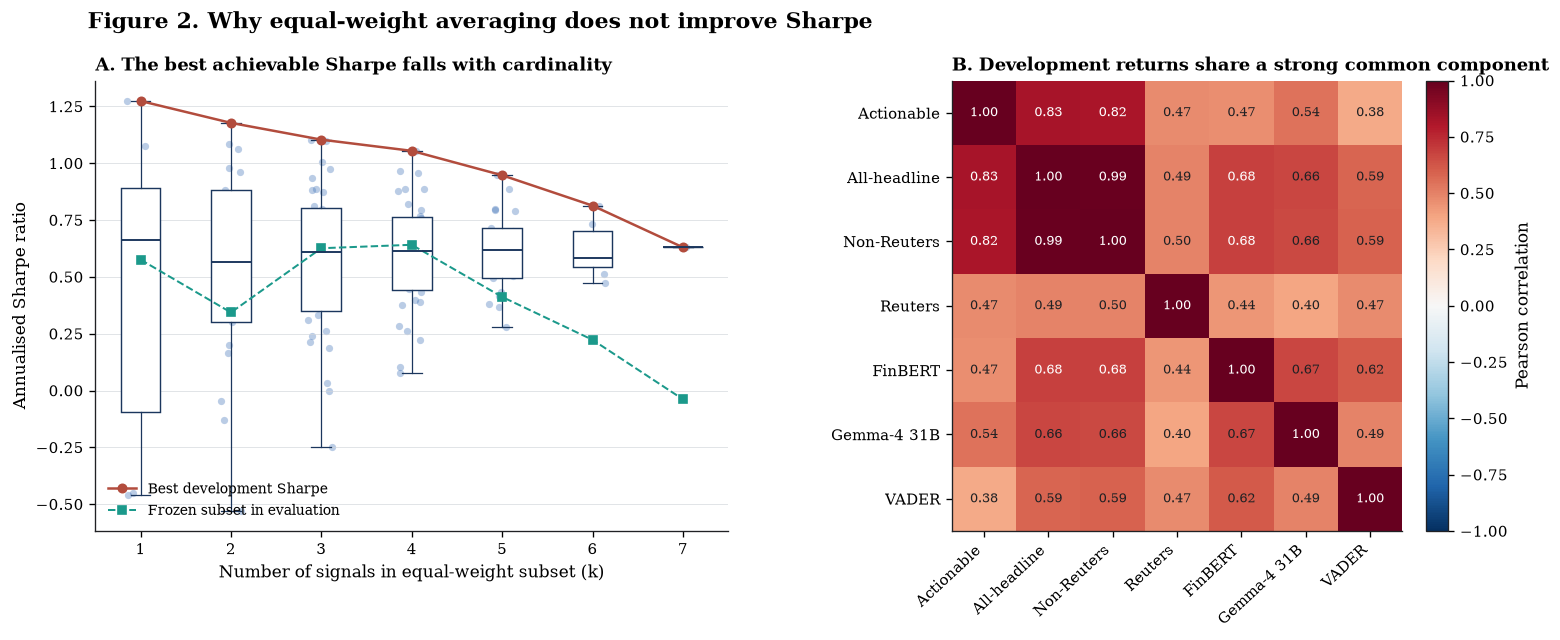

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.35), gridspec_kw={"width_ratios": [1.08, 1.0]})

# A: Distribution of development Sharpe at every cardinality.
rng = np.random.default_rng(SEED)
for size in range(1, 8):
    values = gross_subsets.loc[gross_subsets["size"].eq(size), "development_sharpe"].to_numpy()
    jitter = rng.uniform(-0.15, 0.15, size=len(values))
    axes[0].scatter(np.full(len(values), size) + jitter, values, s=19, color=PALETTE["blue"], alpha=0.35, linewidth=0)
    axes[0].boxplot(
        values, positions=[size], widths=0.44, showfliers=False, patch_artist=True,
        boxprops={"facecolor": "white", "edgecolor": PALETTE["navy"], "linewidth": 0.85},
        medianprops={"color": PALETTE["navy"], "linewidth": 1.15},
        whiskerprops={"color": PALETTE["navy"], "linewidth": 0.75},
        capprops={"color": PALETTE["navy"], "linewidth": 0.75},
    )
axes[0].plot(best_by_k["size"], best_by_k["development_sharpe"], "o-", color=PALETTE["rust"], lw=1.5, ms=5, label="Best development Sharpe")
axes[0].plot(best_by_k["size"], best_by_k["evaluation_sharpe"], "s--", color=PALETTE["teal"], lw=1.2, ms=4.5, label="Frozen subset in evaluation")
axes[0].set_xticks(range(1, 8))
axes[0].set(xlabel="Number of signals in equal-weight subset (k)", ylabel="Annualised Sharpe ratio")
axes[0].set_title("A. The best achievable Sharpe falls with cardinality", loc="left", fontweight="bold")
axes[0].grid(axis="y")
axes[0].legend(loc="lower left")

# B: Development correlation matrix, ordered by source family.
corr = gross_correlations.loc[signal_order, signal_order]
image = axes[1].imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, interpolation="nearest")
labels = [short_signal(s).replace(" lexicon", "") for s in signal_order]
axes[1].set_xticks(range(7), labels, rotation=43, ha="right")
axes[1].set_yticks(range(7), labels)
for i in range(7):
    for j in range(7):
        value = corr.iloc[i, j]
        axes[1].text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8,
                     color="white" if abs(value) > 0.68 else PALETTE["ink"])
axes[1].set_title("B. Development returns share a strong common component", loc="left", fontweight="bold")
colorbar = fig.colorbar(image, ax=axes[1], fraction=0.046, pad=0.04)
colorbar.set_label("Pearson correlation")

fig.suptitle("Figure 2. Why equal-weight averaging does not improve Sharpe", x=0.06, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()


**Figure 2.** Each blue point is one of the 127 candidate subsets; red points are the development maxima within cardinality and green squares apply those already-selected subsets to evaluation. The maximum decreases monotonically from 1.274 at `k=1` to 0.630 at `k=7`. The correlation matrix explains the weak diversification benefit: development correlations range from roughly 0.38 to 0.99, and the All-headline and Non-Reuters lexicons are nested aggregations of the same underlying score.

## 5. Selection luck and transaction costs

In [7]:
from sentiment_benchmark.signal_portfolio import selection_null_distribution

null_result = selection_null_distribution(
    development,
    periods_per_year=gross_manifest["configuration"]["annualization_periods"],
    replications=gross_manifest["configuration"]["bootstrap_replications"],
    block_length=gross_manifest["configuration"]["bootstrap_block_length"],
    seed=gross_manifest["configuration"]["random_seed"],
)
recorded_null = gross_manifest["inference"]["selection_null"]
for key in ("mean_max_sharpe", "median_max_sharpe", "percentile_95_max_sharpe", "maximum_max_sharpe"):
    assert math.isclose(null_result[key], recorded_null[key], rel_tol=0, abs_tol=1e-12)

observed_best = gross_manifest["selection"]["global_best_development_sharpe"]
share_at_or_above = float(np.mean(null_result["distribution"] >= observed_best))
assert share_at_or_above == recorded_null["share_at_or_above_observed"]

pd.DataFrame([{
    "observed max Sharpe": observed_best,
    "null mean max": null_result["mean_max_sharpe"],
    "null 95th percentile": null_result["percentile_95_max_sharpe"],
    "Pr(null max ≥ observed)": share_at_or_above,
    "subsets per replication": null_result["subsets_searched"],
    "replications": null_result["replications"],
}]).style.format(precision=3).hide(axis="index")


observed max Sharpe,null mean max,null 95th percentile,Pr(null max ≥ observed),subsets per replication,replications
1.274,1.411,4.120,0.522,127,2000


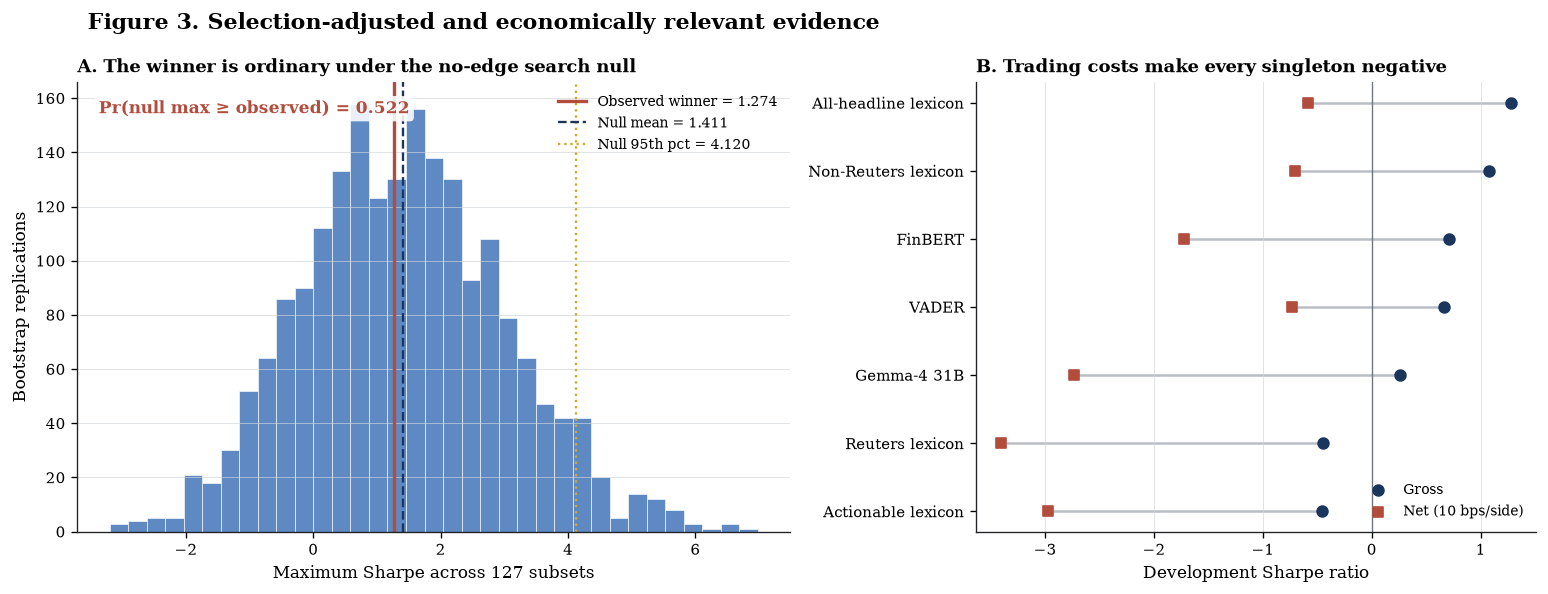

In [8]:
gross_single = gross_subsets.loc[gross_subsets["size"].eq(1), ["signals", "development_sharpe"]].rename(columns={"development_sharpe": "gross"})
net_single = net_subsets.loc[net_subsets["size"].eq(1), ["signals", "development_sharpe"]].rename(columns={"development_sharpe": "net"})
cost_effect = gross_single.merge(net_single, on="signals")
cost_effect["label"] = cost_effect["signals"].map(short_signal)
cost_effect = cost_effect.sort_values("gross")

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.0), gridspec_kw={"width_ratios": [1.12, 0.88]})

# A: Exact selection null distribution.
axes[0].hist(null_result["distribution"], bins=35, color=PALETTE["blue"], alpha=0.82, edgecolor="white", linewidth=0.45)
axes[0].axvline(observed_best, color=PALETTE["rust"], lw=2.0, label=f"Observed winner = {observed_best:.3f}")
axes[0].axvline(null_result["mean_max_sharpe"], color=PALETTE["navy"], lw=1.4, ls="--", label=f"Null mean = {null_result['mean_max_sharpe']:.3f}")
axes[0].axvline(null_result["percentile_95_max_sharpe"], color=PALETTE["gold"], lw=1.4, ls=":", label=f"Null 95th pct = {null_result['percentile_95_max_sharpe']:.3f}")
axes[0].set(xlabel="Maximum Sharpe across 127 subsets", ylabel="Bootstrap replications")
axes[0].set_title("A. The winner is ordinary under the no-edge search null", loc="left", fontweight="bold")
axes[0].text(
    0.03, 0.96, f"Pr(null max ≥ observed) = {share_at_or_above:.3f}",
    transform=axes[0].transAxes, ha="left", va="top",
    color=PALETTE["rust"], fontweight="bold",
    bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": "none", "alpha": 0.88},
)
axes[0].grid(axis="y")
axes[0].legend(loc="upper right")

# B: Gross-to-net cost drag for each individual signal.
y = np.arange(len(cost_effect))
for idx, row in cost_effect.reset_index(drop=True).iterrows():
    axes[1].plot([row["net"], row["gross"]], [idx, idx], color="#B9BEC7", lw=1.5, zorder=1)
axes[1].scatter(cost_effect["gross"], y, color=PALETTE["navy"], s=42, label="Gross", zorder=3)
axes[1].scatter(cost_effect["net"], y, color=PALETTE["rust"], marker="s", s=38, label="Net (10 bps/side)", zorder=3)
axes[1].axvline(0, color=PALETTE["grey"], lw=0.8)
axes[1].set_yticks(y, cost_effect["label"])
axes[1].set_xlabel("Development Sharpe ratio")
axes[1].set_title("B. Trading costs make every singleton negative", loc="left", fontweight="bold")
axes[1].grid(axis="x")
axes[1].legend(loc="lower right")

fig.suptitle("Figure 3. Selection-adjusted and economically relevant evidence", x=0.06, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()


**Figure 3.** Panel A repeats the *entire* 127-subset search within each of 2,000 demeaned overlapping-block bootstrap samples. Preserving cross-signal covariance and short-horizon dependence makes this a selection-procedure null, not a single-strategy test. The null mean maximum (1.411) exceeds the observed winner (1.274), and 52.2% of null searches do at least as well. Panel B shows the independent economic failure: at 10 bps per side, all seven singleton development Sharpes are negative. The winning gross subset breaks even at only 6.86 bps per side.

## 6. Lagrange multiplier solution: correct algebra, unstable portfolio

For two returns with mean vector $\mu$ and covariance $\Sigma$, maximise

$$\frac{w^\top\mu}{\sqrt{w^\top\Sigma w}} \quad \text{subject to} \quad \mathbf{1}^\top w=1.$$

Sharpe is homogeneous of degree zero. Contracting the stationarity condition with $w$ gives $\lambda=0$, leaving

$$w^*=\frac{\Sigma^{-1}\mu}{\mathbf{1}^\top\Sigma^{-1}\mu}.$$

The sign of $d=\mathbf{1}^\top\Sigma^{-1}\mu$ matters: `d > 0` identifies the constrained maximum; `d < 0` identifies a constrained minimum and the supremum is approached only as leverage diverges. Ten of the 21 pairs fall in the latter case.

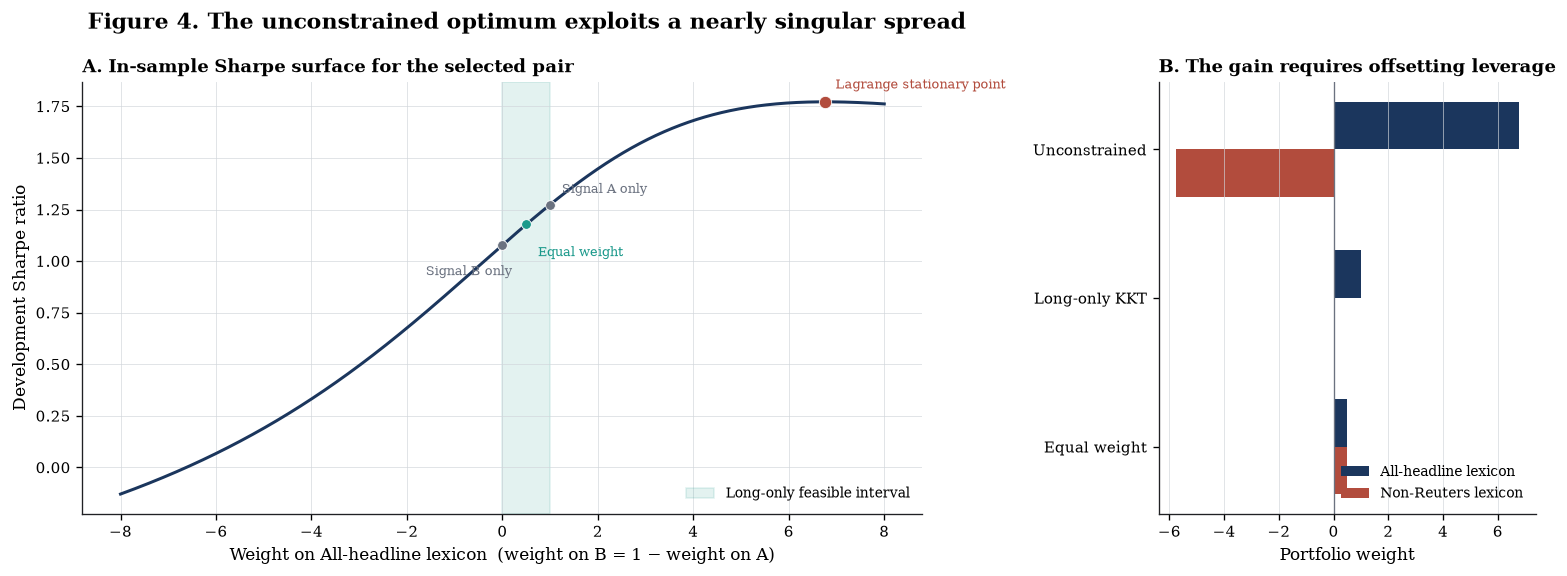

In [9]:
a_name, b_name = best_pair_signals
a_returns = development[a_name].to_numpy()
b_returns = development[b_name].to_numpy()
weight_grid = np.linspace(-8, 8, 1601)
portfolio_grid = weight_grid[:, None] * a_returns + (1 - weight_grid[:, None]) * b_returns
sharpe_grid = np.sqrt(252) * portfolio_grid.mean(axis=1) / portfolio_grid.std(axis=1, ddof=1)

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.85), gridspec_kw={"width_ratios": [1.38, 0.62]})

axes[0].plot(weight_grid, sharpe_grid, color=PALETTE["navy"], lw=1.8)
axes[0].axvspan(0, 1, color=PALETTE["teal"], alpha=0.12, label="Long-only feasible interval")
markers = [
    (0.0, "Signal B only", PALETTE["grey"], (-46, -18)),
    (0.5, "Equal weight", PALETTE["teal"], (7, -19)),
    (1.0, "Signal A only", PALETTE["grey"], (7, 7)),
    (weight_row.weight_a, "Lagrange stationary point", PALETTE["rust"], (6, 8)),
]
for weight, label, color, offset in markers:
    value = np.sqrt(252) * np.mean(weight * a_returns + (1 - weight) * b_returns) / np.std(weight * a_returns + (1 - weight) * b_returns, ddof=1)
    axes[0].scatter(weight, value, s=55 if "Lagrange" in label else 34, color=color, edgecolor="white", linewidth=0.5, zorder=4)
    axes[0].annotate(label, (weight, value), xytext=offset, textcoords="offset points", fontsize=8, color=color)
axes[0].set(xlabel=f"Weight on {short_signal(a_name)}  (weight on B = 1 − weight on A)", ylabel="Development Sharpe ratio")
axes[0].set_title("A. In-sample Sharpe surface for the selected pair", loc="left", fontweight="bold")
axes[0].grid()
axes[0].legend(loc="lower right")

schemes = ["Equal weight", "Long-only KKT", "Unconstrained"]
weights_a = [0.5, weight_row.long_only_weight_a, weight_row.weight_a]
weights_b = [0.5, 1 - weight_row.long_only_weight_a, weight_row.weight_b]
y = np.arange(len(schemes))
height = 0.32
axes[1].barh(y + height / 2, weights_a, height=height, color=PALETTE["navy"], label=short_signal(a_name))
axes[1].barh(y - height / 2, weights_b, height=height, color=PALETTE["rust"], label=short_signal(b_name))
axes[1].axvline(0, color=PALETTE["grey"], lw=0.8)
axes[1].set_yticks(y, schemes)
axes[1].set_xlabel("Portfolio weight")
axes[1].set_title("B. The gain requires offsetting leverage", loc="left", fontweight="bold")
axes[1].grid(axis="x")
axes[1].legend(loc="lower right")

fig.suptitle("Figure 4. The unconstrained optimum exploits a nearly singular spread", x=0.06, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()


**Figure 4.** Signal A is All-headline lexicon and signal B is Non-Reuters lexicon. The unconstrained point, `(6.768, −5.768)`, raises development Sharpe from 1.178 (equal weight) to 1.772, but creates 12.54× gross leverage against a covariance condition number of 180.4. The long-only KKT solution collapses to `(1, 0)`, exactly the free-cardinality singleton. The apparent unconstrained gain is therefore a levered bet on a small estimated mean spread between two 0.989-correlated series, not robust diversification.

## 7. Conclusions

1. **Best pair:** All-headline lexicon + Non-Reuters lexicon, equal weighted; development Sharpe **1.178**.
2. **Best triple:** the pair above + FinBERT; development Sharpe **1.104**.
3. **Unspecified cardinality:** the unique add/drop-stable solution is the singleton **All-headline lexicon**, development Sharpe **1.274**. The best Sharpe decreases monotonically as signals are added.
4. **Weighted pair:** unconstrained Lagrange weights **6.768 / −5.768**, development Sharpe **1.772**. The academically correct practical reading is instability: the long-only solution is **1 / 0**.
5. **Statistical verdict:** the observed winner is not unusual under the no-edge selection null (`p = 0.522` as a selection-adjusted exceedance share), and its Lo standard error is larger than the differences being ranked.
6. **Economic verdict:** all seven singleton net Sharpes are negative at 10 bps per side; the gross winner's breakeven cost is **6.86 bps per side**.

**Stop rule:** the optimisation methods are fully implementable and auditable, but this panel does not support a claim that combining the seven signals improves risk-adjusted performance. A defensible next study would freeze the design on a genuinely new time period and, if weighted portfolios are required, preregister a long-only or regularised covariance estimator rather than use the unstable sample-covariance tangency portfolio.

## Reproduction notes

- Source runs: `results/signal_portfolio/sentiment_signal_portfolio_{gross,net}_h1_20260729/`.
- Random seed: `20260729`; bootstrap seed for the frozen-winner interval in the run: `20260730`.
- Selection null: 2,000 overlapping moving-block replications, block length 5, with every one of the 127 subsets re-searched in every replication.
- Input paths and SHA-256 hashes are recorded in each run's `manifest.json`; this notebook additionally verifies every recorded output artifact before analysis.
- Full method and limitations: `docs/sentiment_signal_portfolio.md`.
